The specific tasks include:
1)	Identify the states that are generating the highest revenues.
2)	Develop sales programs for states with lower revenues. The head of sales and marketing has requested your assistance with this task.
Analyze the sales data of the company for the fourth quarter in Australia, examining it on a state-by-state basis. Provide insights to assist the company in making data-driven decisions for the upcoming year.
*Enclosed is the CSV (AusApparalSales4thQrt2020.csv) file that covers the said data.

Perform the following steps:
As a data scientist, you must perform the following steps on the enclosed data:
1.	Data wrangling
2.	Data analysis
3.	Data visualization
4.	Report generation
1.	Data wrangling
a.	Ensure that the data is clean and free from any missing or incorrect entries.
○	Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().
b.	Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them).
c.	Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem.)
d.	Share your insights regarding the application of the GroupBy() function for either data chunking or merging, and offer a recommendation based on your analysis.
2.	Data analysis
a.	Perform descriptive statistical analysis on the data in the Sales and Unit columns. Utilize techniques such as mean, median, mode, and standard deviation for this analysis.
b.	Identify the group with the highest sales and the group with the lowest sales based on the data provided.
c.	Identify the group with the highest and lowest sales based on the data provided.
d.	Generate weekly, monthly, and quarterly reports to document and present the results of the analysis conducted.
(Use suitable libraries such as NumPy, Pandas, and SciPy for performing the analysis.)
3.	Data visualization
a.	Use suitable data visualization libraries to construct a dashboard for the head of sales and marketing. The dashboard should encompass key parameters:
o	State-wise sales analysis for different demographic groups (kids, women, men, and seniors).
o	Group-wise sales analysis (Kids, Women, Men, and Seniors) across various states.
o	Time-of-the-day analysis: Identify peak and off-peak sales periods to facilitate strategic planning for S&M teams. This information aids in designing programs like hyper-personalization and Next Best Offers to enhance sales.
b.	Ensure the visualization is clear and accessible for effective decision-making by the head of sales and marketing (S&M).
The dashboard must contain daily, weekly, monthly, and quarterly charts.
(Any visualization library can be used for this purpose. However, since statistical analysis is being done, Seaborn is preferred.)
c.	Include your recommendation and indicate why you are choosing the recommended visualization package.
4.	Report generation 
a)	Use JupyterLab Notebook for generating reports, which includes tasks such as data wrangling, analysis, and visualization. Please note that JupyterLab enables you to integrate code seamlessly with graphs and plots.
b)	Use Markdown in suitable places while presenting your report. 
c)	Use suitable graphs, plots, and analysis reports in the report, along with recommendations. Note that various aspects of analysis require different graphs and plots.
○	Use a box plot for descriptive statistics.
○	Use the Seaborn distribution plot for any other statistical plotting.


In [135]:
# Priliminary data analysis (EDA)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import the CSV file into a pandas DataFrame and create a DataFrame object called df.
df = pd.read_csv("AusApparalSales4thQrt2020.csv")
#Get information about he data frame , datatypes of each column, and summary statistics for numerical columns.
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB
None
              Unit          Sales
count  7560.000000    7560.000000
mean     18.005423   45013.558201
std      12.901403   32253.506944
min       2.000000    5000.000000
25%       8.000000   20000.000000
50%      14.000000   35000.000000
75%      26.000000   65000.000000
max      65.000000  162500.000000


### Observations
- Mean (18) vs Median (14) — the mean is notably higher than the median, suggesting right skew
- Its a right-skewed distribution.

In [136]:
#a. Inspecting data for any missing values
print(df.isnull().sum())

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


### Observations
- Data is pretty clean. 
- No missing values 

In [137]:
#b. How to drop missing values
df.dropna(inplace=True) # drop rows with missing values (if any) and update the DataFrame in place
print(df.isnull().sum()) # verify that there are no more missing values

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


In [138]:
#Time based analysis
df['Order Date'] = pd.to_datetime(df['Date']) # convert 'Order Date' column to datetime format
df['Month'] = df['Order Date'].dt.month # extract month from 'Order Date' and create a new 'Month' column
print(df)

             Date        Time State     Group  Unit  Sales Order Date  Month
0      1-Oct-2020     Morning    WA      Kids     8  20000 2020-10-01     10
1      1-Oct-2020     Morning    WA       Men     8  20000 2020-10-01     10
2      1-Oct-2020     Morning    WA     Women     4  10000 2020-10-01     10
3      1-Oct-2020     Morning    WA   Seniors    15  37500 2020-10-01     10
4      1-Oct-2020   Afternoon    WA      Kids     3   7500 2020-10-01     10
...           ...         ...   ...       ...   ...    ...        ...    ...
7555  30-Dec-2020   Afternoon   TAS   Seniors    14  35000 2020-12-30     12
7556  30-Dec-2020     Evening   TAS      Kids    15  37500 2020-12-30     12
7557  30-Dec-2020     Evening   TAS       Men    15  37500 2020-12-30     12
7558  30-Dec-2020     Evening   TAS     Women    11  27500 2020-12-30     12
7559  30-Dec-2020     Evening   TAS   Seniors    13  32500 2020-12-30     12

[7560 rows x 8 columns]


In [139]:
#Map Month numbers to month names
month_mapping = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
                 7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
df['Month'] = df['Month'].map(month_mapping) # map month numbers to month names in the 'Month' column
print(df)

             Date        Time State     Group  Unit  Sales Order Date  \
0      1-Oct-2020     Morning    WA      Kids     8  20000 2020-10-01   
1      1-Oct-2020     Morning    WA       Men     8  20000 2020-10-01   
2      1-Oct-2020     Morning    WA     Women     4  10000 2020-10-01   
3      1-Oct-2020     Morning    WA   Seniors    15  37500 2020-10-01   
4      1-Oct-2020   Afternoon    WA      Kids     3   7500 2020-10-01   
...           ...         ...   ...       ...   ...    ...        ...   
7555  30-Dec-2020   Afternoon   TAS   Seniors    14  35000 2020-12-30   
7556  30-Dec-2020     Evening   TAS      Kids    15  37500 2020-12-30   
7557  30-Dec-2020     Evening   TAS       Men    15  37500 2020-12-30   
7558  30-Dec-2020     Evening   TAS     Women    11  27500 2020-12-30   
7559  30-Dec-2020     Evening   TAS   Seniors    13  32500 2020-12-30   

         Month  
0      October  
1      October  
2      October  
3      October  
4      October  
...        ...  
7555

### Data Analysis

In [140]:
# Finding out which month had the highest sales
monthly_sales = df.groupby('Month')['Sales'].sum() # group by 'Month' and sum the 'Sales' for each month
print(monthly_sales) # print the total sales for each month to verify the grouping and summation

Month
December    135330000
November     90682500
October     114290000
Name: Sales, dtype: int64


### Observations 
- December has highest number of sales due to holiday season , i guess

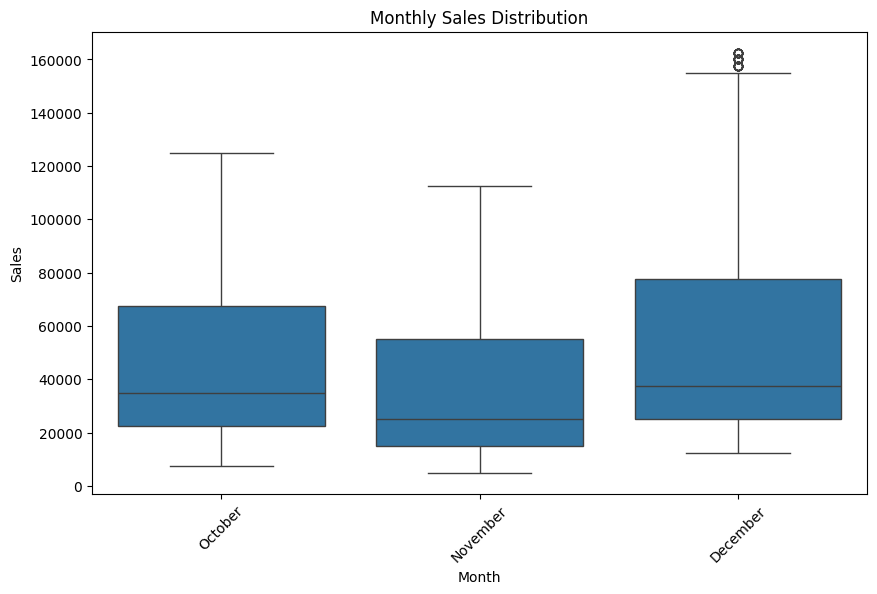

In [141]:
#Plotting the sales distribution across months
plt.figure(figsize=(10, 6)) # set the figure size for the plot
#use the box plot to visualize the distribution of sales across different months
sns.boxplot(x='Month', y='Sales', data=df) # create a box plot of sales distribution across months
plt.title('Monthly Sales Distribution') # set the title of the plot
plt.xlabel('Month') # set the x-axis label
plt.ylabel('Sales') # set the y-axis label
plt.xticks(rotation=45) # rotate x-ticks for better readability
plt.show() # display the plot


In [142]:
# Finding out which time of day had the highest sales
hourly_sales = df.groupby('Time')['Sales'].sum() # group by 'Time' and sum the 'Sales' for each hour
print(hourly_sales.sort_values(ascending=False)) # print the total sales for each hour sorted in descending order

Time
Morning      114207500
Afternoon    114007500
Evening      112087500
Name: Sales, dtype: int64


### Observations
- Morning has most sales
- Evening time has less sales compartively 

In [143]:
# Finding out which clothes category had the highest sales
category_sales = df.groupby('Group')['Sales'].sum() # group by 'Group' and sum the 'Sales' for each group
print(category_sales.sort_values(ascending=False)) # print the total sales for each group sorted in descending order

Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64


### Observations
- Men section has more sales 

In [144]:
# Finding which states had the highest sales
state_sales = df.groupby(['State', 'Group'])['Sales'].sum() # group by 'State' , 'Group' and sum the 'Sales' for each state

print(state_sales.sort_values(ascending=False)) # print the total sales for each state sorted in descending order   

State  Group  
VIC    Women      26482500
       Men        26407500
       Kids       26360000
       Seniors    26315000
NSW    Women      19172500
       Men        19022500
       Kids       18587500
       Seniors    18187500
SA     Women      14970000
       Seniors    14717500
       Men        14655000
       Kids       14515000
QLD    Kids        8510000
       Men         8392500
       Women       8325000
       Seniors     8190000
TAS    Kids        5775000
NT     Men         5762500
TAS    Men         5757500
WA     Men         5752500
NT     Kids        5700000
       Women       5652500
TAS    Seniors     5650000
WA     Kids        5625000
TAS    Women       5577500
WA     Seniors     5512500
NT     Seniors     5465000
WA     Women       5262500
Name: Sales, dtype: int64


In [ ]:
# Mapping the State column to actual state names 
df['State'] = df['State'].str.strip() # remove leading and trailing whitespace from
# create a mapping dictionary to map state codes to state names
state_mapping = {'NSW': 'New South Wales', 'VIC': 'Victoria', 'QLD': 'Queensland', 'SA': 'South Australia', 'WA': 'Western Australia', 'TAS': 'Tasmania', 'NT': 'Northern Territory', 'ACT': 'Australian Capital Territory'}
df['State'] = df['State'].map(state_mapping) # map state codes to state names in the 'State' column


In [147]:
# Using Piviot tables to analyze sales by state and group
pivot_table = df.pivot_table(values='Sales', index='State', columns='Group', aggfunc='sum') # create a pivot table to analyze sales by state and group
#print the pivot table to verify the results in descending order of total sales
print(pivot_table.sort_values(by=pivot_table.columns.tolist(), ascending=False))    

Group                   Kids       Men   Seniors     Women
State                                                     
Victoria            26360000  26407500  26315000  26482500
New South Wales     18587500  19022500  18187500  19172500
South Australia     14515000  14655000  14717500  14970000
Queensland           8510000   8392500   8190000   8325000
Tasmania             5775000   5757500   5650000   5577500
Northern Territory   5700000   5762500   5465000   5652500
Western Australia    5625000   5752500   5512500   5262500


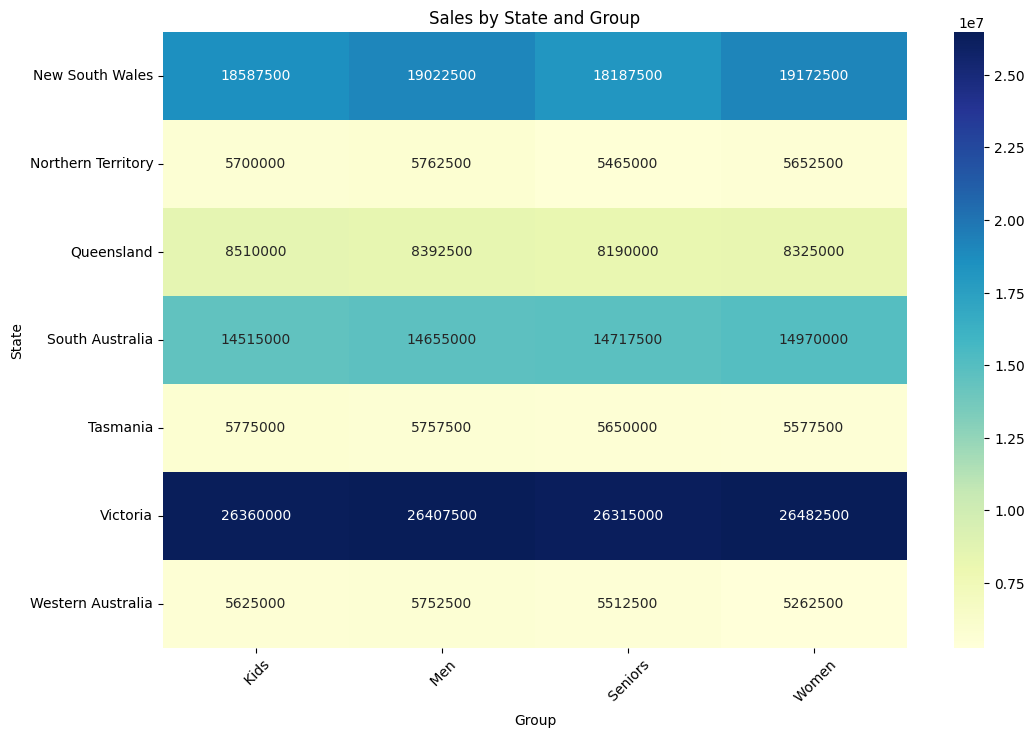

In [ ]:
#Dashboard to visualize the sales data by state and group using the pivot table
plt.figure(figsize=(12, 8)) # set the figure size for the plot
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu") # create a heatmap to visualize sales by state and group
plt.title('Sales by State and Group') # set the title of the plot
plt.xlabel('Group') # set the x-axis label
plt.ylabel('State') # set the y-axis label
plt.xticks(rotation=45) # rotate x-ticks for better readability
plt.yticks(rotation=0) # keep y-ticks horizontal for better readability
plt.show() # display the plot

#### Suggestions to S&M team. Recommendations for Sales & Marketing

High-Performing States (VIC, NSW, SA):

- Consider opening more stores/distribution units to capitalize on existing demand.
Focus on premium product offerings and upselling strategies.

Low-Performing States (QLD, TAS, NT, WA):

- Implement targeted promotions, discounts, and latest-style campaigns to stimulate demand.
Explore hyper-personalization and Next Best Offer (NBO) strategies during peak morning hours.

Seasonal Strategy:

- Prioritize stock and staffing increases in December to leverage the holiday shopping surge.
Develop specific campaigns for November (lowest month) to boost off-peak revenue.

Time-of-Day Strategy:

- Since morning shows the highest sales, consider morning-specific flash sales or promotions to further amplify peak-period performance.


In [148]:
# Feature scaling with MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler() # create an instance of the MinMaxScaler
df['Sales_MinMaxScaled'] = min_max_scaler.fit_transform(df[['Sales']]) # scale the 'Sales' column using MinMaxScaler and create a new 'Sales_MinMaxScaled' column
print(df[['Sales', 'Sales_MinMaxScaled']].head()) # print the original and MinMax scaled sales values to verify the scaling

   Sales  Sales_MinMaxScaled
0  20000            0.095238
1  20000            0.095238
2  10000            0.031746
3  37500            0.206349
4   7500            0.015873
